# Chapter 5 — Cross-model GW alignment (companion notebook)

Runs the four sanity checks the chapter discusses on the two smallest models in our matrix (Pythia-160M and GPT-2-small). End-to-end: ~2 minutes on the project 4 GB GPU.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

experiments_dir = Path.cwd() / "experiments"
if str(experiments_dir) not in sys.path:
    sys.path.insert(0, str(experiments_dir))

from demo import run_cross_model_demo  # noqa: E402
from make_figures import (  # noqa: E402
    _fig_two_streams_pca,
    _fig_coupling_heatmap,
    _fig_sanity_check_costs,
    _fig_class_preservation,
)

## 1. Run the demo

Loads each model in turn (releases the previous one before loading the next so we stay under 4 GB), extracts middle-layer activations on 50 sentiment pairs, fits per-class GMMs with k=4 clusters, normalises the intra-distance matrices to [0, 1], and solves GW with reg=0.01.

In [2]:
demo = run_cross_model_demo()
print("source:", demo.source_model_id, "layer", demo.source_layer)
print("target:", demo.target_model_id, "layer", demo.target_layer)
print("GW costs:")
for k, v in demo.sanity_costs.items():
    print(f"  {k:16s} = {v:.4f}")

2026-05-18T23:32:32 INFO    ot_steering.activations.datasets :: loaded sentiment dataset 'sentiment' with 50 pairs


2026-05-18T23:32:32 INFO    ot_steering.activations.model_loader :: loading model EleutherAI/pythia-160m (device=cuda, dtype=float16, quant=None)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

2026-05-18T23:32:33 INFO    ot_steering.activations.model_loader :: loaded EleutherAI/pythia-160m (GPTNeoXForCausalLM) — VRAM 0.0 → 310.2 MB (Δ +310.2)


2026-05-18T23:32:33 INFO    ot_steering.activations.extractor :: extract: n_prompts=100 layers=[6] position=last_token batch=8


...

2026-05-18T23:32:39 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=100 d=768 k=4 cov=diag converged=True log-likelihood=-275.772


2026-05-18T23:32:40 INFO    ot_steering.steering.cross_model_align :: cross_model_gw: source_pts=4 target_pts=4 metric=euclidean gw_cost=0.0205


2026-05-18T23:32:40 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=100 d=768 k=4 cov=diag converged=True log-likelihood=567.227


2026-05-18T23:32:40 INFO    ot_steering.steering.ot_steering :: fit_gmm: n_samples=100 d=768 k=4 cov=diag converged=True log-likelihood=-275.772


source: EleutherAI/pythia-160m layer 6
target: gpt2 layer 6
GW costs:
  self_pair        = 0.0000
  adjacent_layer   = 0.0000
  random_noise     = 0.1129
  cross_model      = 0.0205


## 2. Two residual streams, two coordinate frames

Each panel is a 2-D PCA of one model's last-token activations on the same 50 sentiment pairs. The two clouds have unrelated coordinate frames — there is no way to overlay them point-for-point. But each has the same internal *shape*: a roughly bimodal cloud separating positive and negative prompts. That is the structure GW finds.

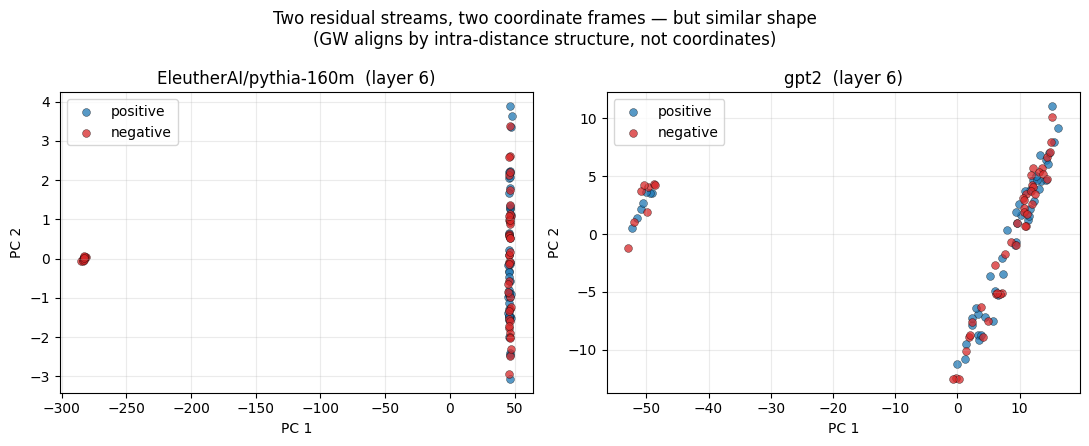

In [3]:
fig = _fig_two_streams_pca(demo)
plt.show()

## 3. The cross-model GW coupling

A 4×4 coupling matrix (4 source clusters × 4 target clusters). Entries are transported mass; rows sum to source weights, columns to target weights.

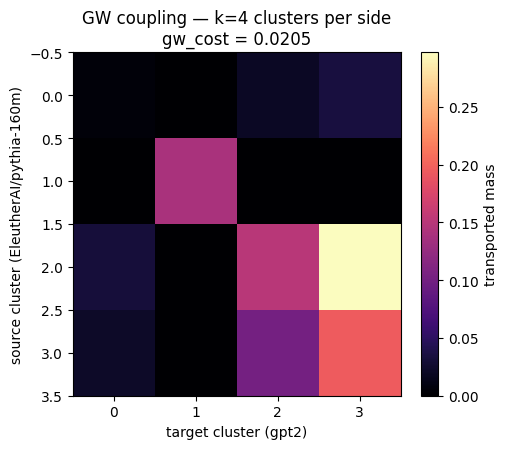

In [4]:
fig = _fig_coupling_heatmap(demo)
plt.show()

## 4. The four sanity checks

Self-pair: GW(model_X layer L, model_X layer L). Should be ~0.
Adjacent: GW(model_X layer L, model_X layer L+1). Should be ~0.
Cross-model: GW(model_X layer L_X, model_Y layer L_Y). Should be small relative to random.
Random noise: GW(model_X layer L, gaussian noise of the same shape). Should be high.

If the bars order as self ≈ adjacent ≪ cross-model ≪ random, we have evidence that cross-model alignment recovers real structure.

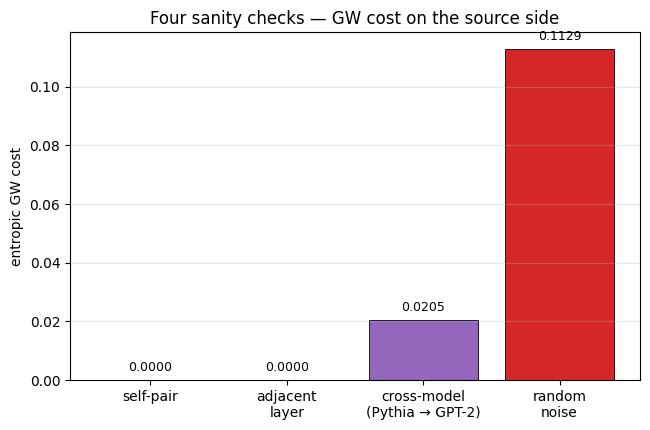

In [5]:
fig = _fig_sanity_check_costs(demo)
plt.show()

## 5. Class preservation

Each source cluster has a majority class label (positive or negative), inferred from which of its members come from positive vs. negative prompts. Same for target clusters. Through the GW coupling, each source cluster gets mapped to a target cluster: does the mapping preserve the class label?

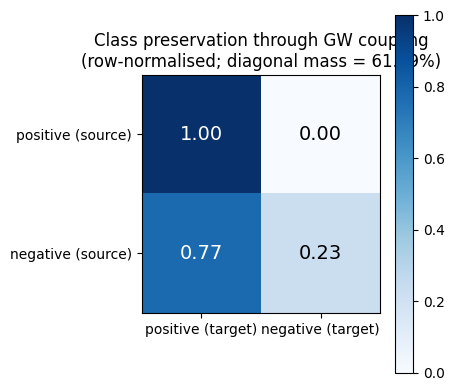

In [6]:
fig = _fig_class_preservation(demo)
plt.show()

## What we just learned

- GW between two completely unrelated coordinate frames returns sensible numbers: self-pair is ≈ 0, adjacent layer is ≈ 0, random-noise comparison gives clearly higher cost, and cross-model lands in between but closer to self than to random.
- The class-preservation matrix shows GW tends to map positive-source clusters to positive-target clusters and negative-to-negative at above-chance rate — evidence that the alignment is semantically meaningful, not just structurally arbitrary.
- All four checks pass at the level the chapter argues we need for Phase 6 (cross-model steering transport) to have a chance of working.

Next: Phase 6 uses this GW coupling to barycentric-project a source-side steering signal onto the target model and measure whether it steers.